## GAN training

Your task is to train a generator that will generate samples from a 1D Gaussian with the goal of approximating the true Gaussian distribution centered around a true mean (review class example). Use binary cross-entropy to train both the generator and discriminator. Propagate the losses to the correct parameters.  Track the losses of both generator and discriminator and plot them. Finally, plot the discriminator’s probability function for various epochs during training.

Comment on any interesting behavior you notice. Change the learning rates for both gen/dis, what do you notice?

Bonus: Modify the training loop for stochastic gradient descent (one example at a time). What can you say about the loss graphs of the generator/discriminator compared to the ones trained with gradient descent?

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='jshtml')
#%matplotlib inline
from IPython.display import Math, HTML
display(HTML("<script src='https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.3/"
               "latest.js?config=default'></script>"))

Matplotlib is building the font cache; this may take a moment.


## Training a Generator-Discriminator pair

We train a generator to generate 1D Gaussian examples and a discriminator to distinguish between real data and generated data.
Let $M$ be the true mean of the sample distribution.

Given a random sample of normal Gaussian noise $\{z_1, \dots, z_m\}$, our generator generates synthesized examples according to:

$$x_j = z_j + \theta$$

for all $j \in [m]$. The generator tries to find a $\theta$ to fool the discriminator. Ideally this would be close to $M$, the true mean.

Given $\{x_j\}_{j \in [m]}$ fake data all labeled $0$ and $\{x_{i}\}_{i= m+1}^{m+n}$ real data all labeled $1$, the discriminator parametrized by $\phi = (\beta_0, \beta_1)$ gives a probability of real-ness:
$$p(x) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$
where $\beta_0 = -\frac{\mu}{s}, \beta_1 = \frac{1}{s}$ with $\mu$ the location parameter (mid-point of the curve where $p(x) = 0.5$) and $s$ a scale parameter. The discriminator finds $\phi$ to distinguish synthesized samples from real samples.


In [2]:
class Gen:
    def __init__(self, theta=0.1, lr=0.1):
        self.theta = theta
        self.lr = lr

    def generate(self, z):
        return z + self.theta

    def optimize(self, grad):
        # Gradient descent step
        self.theta = self.theta - (self.lr * grad)

class Dis:
    def __init__(self, phi=[0.1,0.1], lr=0.1): # Trust, initializing phi=[0, 0] is not a good idea.
        self.phi = phi
        self.lr = lr

    def evaluate(self, z):
        a = self.phi[0] * np.ones(shape=z.shape[0])
        tmp = self.phi[1] * np.ones(shape=z.shape[0])
        b = tmp*z
        return sigmoid(a + b)

    def optimize(self, grad):
        # Gradient descent step
        tmp = np.ones(shape=grad.shape[0]) * self.lr
        self.phi = self.phi - tmp*grad

Some utility functions:

In [3]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def grad_sigmoid(z):
        return sigmoid(z) * (1 - sigmoid(z))

def p(x, beta_0, beta_1):
    return sigmoid(beta_0 + beta_1*x)

The loss of choice is the binary cross-entropy loss:

In [4]:
def bce_loss(predicted_labels, true_labels):
  return -true_labels * np.log1p(predicted_labels) - (1-true_labels) * np.log1p(1-predicted_labels)

We set some parameters for our problem. Play around with these and see how it changes training.

In [5]:

# Set the true mean
M = 6

# Set the amount of fake generated samples and true samples.
m, n = 30, 60

# Training epochs
epochs = 2000

## Training loop

In one "epoch" of training, we will loop over several iterations of generator training and several iterations of discriminator training.

## Training the generator

Recall that generated samples are of the form $x = z + \theta$ where $z$ is a standard normal random variable. The training of the generator is as follows.

1. A synthesized sample $S^m = \{x_i\}_{i=1}^m$ is generated.
2. The synthesized sample is passed through the discriminator, $\hat{y}_i = \sigma(\beta_0 + \beta_1x_i)$.
3. We are looking to update the generator's parameter $\theta$ with respect to the feedback from the BCE loss
$$L(\hat{y}, y) = - y\log(\hat{y}) - (1-y)\log(1-\hat{y})$$
with true label $y = 1$ for all synthesized samples.
4. Gradients are computed for all samples in the synthesized batch:
\begin{align}
    \partial_{\theta}L &= \partial_{p}L\cdot \partial_x p \cdot \partial_\theta x\\
    &= -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} \cdot \sigma(\beta_0 + \beta_1x)(1-\sigma(\beta_0 + \beta_1x))\beta_1 \cdot 1
\end{align}
Note that at this step we have calculated gradients for all data points in the synthesized sample. We take an average of all these gradients and update $\theta$ accordingly.

$$\theta \leftarrow \theta - \eta \mathbb{E}_{S^m}[\partial_\theta L]$$

where $\eta$ is some learning rate.

## Training the discriminator

There are several ways to do this. In this tutorial, we proceed with the following.

1. Generate fake samples $S^m$ and mix them with a real sample $S^n$.
2. The sample points from $S^m$ are labeled 0 while the sample points from $S^n$ are labeled 1.
3. We pass the concatenated $S^{m+n}$ through the discriminator to obtain $\hat{y}_i = \sigma(\beta_0 + \beta_1 x_i)$ for $i \in [m+n]$.
4. We calculate gradients of the BCE loss function with respect to parameters $\phi = (\beta_0, \beta_1)$ as follows:
\begin{align}
\partial_{\beta_0}L&= \partial_p L\cdot \partial_{\beta_0}p\\
&= -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} \cdot \sigma(\beta_0 + \beta_1x)(1-\sigma(\beta_0 + \beta_1x))
\end{align}
and
\begin{align}
\partial_{\beta_1}L&= \partial_p L\cdot \partial_{\beta_1}p\\
&= -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} \cdot \sigma(\beta_0 + \beta_1x)(1-\sigma(\beta_0 + \beta_1x))x
\end{align}

Again, we average the computed gradients for $\phi$ and we update the discriminator's parameters accordingly.
$$\beta_0 \leftarrow \beta_0 - \eta\mathbb{E}_{S^{m+n}}[\partial_{\beta_0}L]$$
$$\beta_1 \leftarrow \beta_1 - \eta\mathbb{E}_{S^{m+n}}[\partial_{\beta_1}L]$$

where $\eta$ is some learning rate.

We hand-code the training loop ourselves because we can.


with true label  𝑦=1  for all synthesized samples (why? discuss)

we need true labels = 1, so that the second part of the Loss function will be 0, it's going to be easier for us to do the computation and derivative. and we have all the generatied date labelled 0, which will help us to do the 0-1 loss and cross entropy loss derivative.


In [6]:
def train(gen_train_steps=1, dis_train_steps=2):
    for i in range(gen_train_steps):
        # Generate some fake data
        noise = np.random.normal(size=m)
        fake_data = generator.generate(noise)


        # What does the discriminator think?
        discriminator_out = discriminator.evaluate(fake_data)

        # Compute the loss of the generator.
        gen_labels = np.ones(shape=discriminator_out.shape[0])
        gen_loss = bce_loss(gen_labels, fake_data)

        # compute gradients dL/dtheta
        dL_dyhat = (-(gen_labels/discriminator_out)) + ((1-gen_labels)/(1-discriminator_out))
        dyhat_dx =  discriminator_out* (1-discriminator_out)*discriminator.phi[1]
        dx_dtheta = 1
        dL_dtheta = dL_dyhat * dyhat_dx * dx_dtheta

        # average the gradients
        dL_dtheta = 1/fake_data.shape[0] * np.sum(dL_dtheta)

        # optimize
        generator.optimize(dL_dtheta)

    for i in range(dis_train_steps):
        # Get some real data and mix it with fake data
        real_data = np.random.normal(loc=M, size=n)
        noise = np.random.normal(size=m)
        fake_data = generator.generate(noise)
        data = np.concatenate([fake_data, real_data])
        labels = np.concatenate([np.zeros(shape=fake_data.shape[0]), np.ones(shape=real_data.shape[0])])


        # Pass data through discriminator, compute loss
        discriminator_out = discriminator.evaluate(data)
        dis_loss = bce_loss(discriminator_out, labels)

        # compute gradients dL/dbeta0 and dL/dbeta1
        dL_dyhat = -(labels/discriminator_out)+ ((1-labels)/(1-discriminator_out))
        dyhat_dbeta0 = discriminator_out*(1-discriminator_out)
        dyhat_dbeta1 = discriminator_out*(1-discriminator_out) * data
        #
        dL_dbeta0 = dL_dyhat * dyhat_dbeta0
        dL_dbeta1 = dL_dyhat * dyhat_dbeta1

        # average the gradients
        dL_dbeta0 = 1/data.shape[0] * np.sum(dL_dbeta0)
        dL_dbeta1 = 1/data.shape[0] * np.sum(dL_dbeta1)

        # optimize
        discriminator.optimize(np.array([dL_dbeta0, dL_dbeta1]))

    return np.mean(gen_loss), np.mean(dis_loss)

def print_stats():
    print("Generator mean: {}".format(generator.theta))

A very kind reminder that the entirety of the loss propagation can be done automatically in pytorch.

We are now ready to loop over the training loop. Try to play with the number of generator optimization steps as well as the discriminator training steps and see how it changes the graphs below. What happens when you optimize the generator a bunch before optimizing the discriminator once? What about optimizing the generator once while optimizing the discriminator a bunch?

Try playing with the learning rates of the generators and discriminators. What happens when you increase the LR of the generator and why? How about the discriminator?

first we fix the generator training loop number as 1, and we vary the number of discriminator loops

number of discriminator loops; learning rate:

20; 0.1 :it converges after 750 ephoches

20; 0.2: we can see discriminator converges faster, however, the generater and generator parameters are the same

40; 0.1: by increasing the number of training loops, i observe that thediscriminator loss oscilating less, and thus the generator parameters are converging faster and oscilating less

now we change the parameter of generator training:

we fix the number of discriminator loop to 1

number of generator training loops; learning rate:

10; 0.1 we can see that first two losses are converging at a relatively low level, thus it result in the late convergence and big oscialtion in the generator paramenters

10; 0.2: by changing the learing rate, the generator BCE loss converge faster and the parameter converging faster

25; 0.1: by increasing the training loops of the generators, we can also increase the speed of gen parameter converging


In [7]:
# Instantiate our gen/dis objects
generator = Gen(theta=0.0, lr=0.1)
discriminator = Dis(lr=0.1)

# Saving some training data
gen_loss, dis_loss = [], []
gen_theta = []
dis_phi = []
for i in range(epochs):
    g, d = train(gen_train_steps=30, dis_train_steps=1)

    # Save the losses of the generator and discriminator
    gen_loss.append(g)
    dis_loss.append(d)
    gen_theta.append(generator.theta)
    dis_phi.append(discriminator.phi)

gen_theta = np.array(gen_theta)
dis_phi = np.array(dis_phi)

## Some cool plots

Text(0.5, 1.0, 'Generator BCE Loss over epochs')

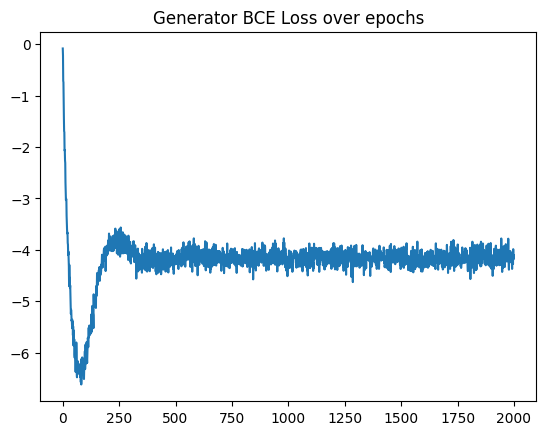

In [8]:
# Plot the generator loss
plt.plot(gen_loss)
plt.title("Generator BCE Loss over epochs")

Text(0.5, 1.0, 'Discriminator BCE loss over epochs')

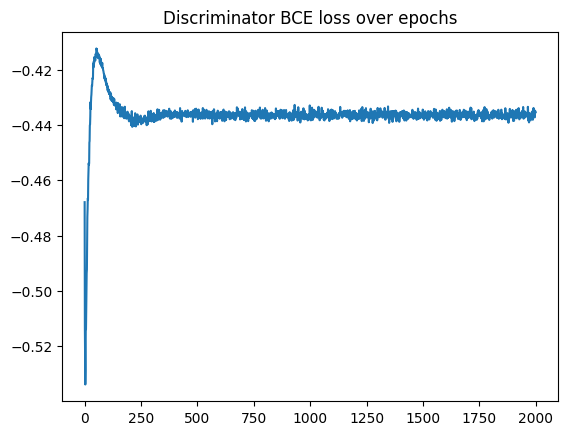

In [9]:
# Plot the discriminator loss
plt.plot(dis_loss)
plt.title("Discriminator BCE loss over epochs")

Text(0.5, 1.0, 'Generator parameter over epochs')

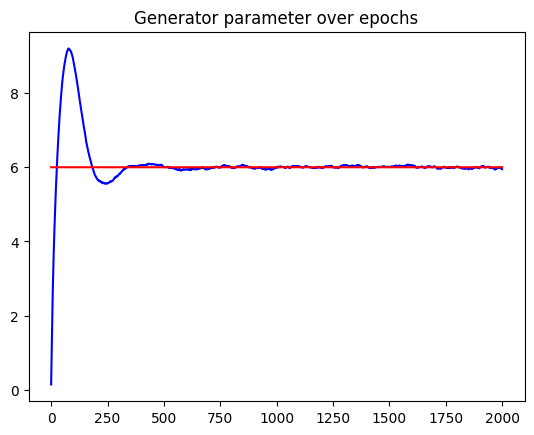

In [10]:
# Plot the generator's mean parameter over epochs. It should converge to the true mean.
plt.plot(np.arange(epochs), gen_theta, c='b')
plt.plot(np.arange(epochs), np.ones(shape=(epochs,))*M, c='r')
plt.title("Generator parameter over epochs")

In the above, colored in red is the true mean.

Below is the code to animate the probability curves over the training epochs of the discriminator. This will not run on google colab because colab is cringe. You can download this code and it will run fine on your jupyter notebook instance.

There is a function that saves your animation as a gif file that is commented out at the end. If you would like to, you can share your gif of the discriminator training over time on an Ed post.

In [11]:
"""
IMPORTANT: This only works if you run the notebook on your computer.
Google Colab is cringe and cannot plot this.
"""
%matplotlib notebook
xmin, xmax, ymin, ymax = -30, 30, 0, 1
fig, ax = plt.subplots(1,1)
x_ax = np.linspace(xmin, xmax, 200)
scale = 5

def animate(i):
    ax.clear()
    phi = dis_phi[i*scale]
    print(phi)
    ax.plot(x_ax, p(x_ax, phi[0], phi[1]))
    ax.axis([xmin, xmax, ymin, ymax])
    ax.set_title('Epoch: {}'.format(i*scale),
                 fontsize=20)

ani = FuncAnimation(fig, animate, frames=np.int32(np.floor(2000/scale)), interval=100, repeat=True)
'''
Run this below to save your plot.

from matplotlib.animation import PillowWriter
# Save the animation as an animated GIF
ani.save("Probabilities.gif",
         dpi=300, writer=PillowWriter(fps=60))
'''
from matplotlib.animation import PillowWriter
# Save the animation as an animated GIF
ani.save("Probabilities.gif",
         dpi=300, writer=PillowWriter(fps=60))

<IPython.core.display.Javascript object>

[0.10474644 0.2248993 ]
[0.10474644 0.2248993 ]
[0.0478837 0.341779 ]
[-0.02403772  0.26253644]
[-0.0693143   0.19418403]
[-0.09337817  0.16619176]
[-0.10231741  0.13273985]
[-0.09640819  0.11164744]
[-0.08174646  0.09034426]
[-0.05776544  0.07178209]
[-0.02483288  0.06598591]
[0.01054361 0.05980234]
[0.05440846 0.0433896 ]
[0.09665136 0.02563712]
[0.1433624  0.02292215]
[0.18776656 0.01748347]
[0.23546006 0.00487593]
[ 0.28608704 -0.00844849]
[ 0.33695038 -0.0074595 ]
[ 0.38471633 -0.01203185]
[ 0.43212371 -0.01582448]
[ 0.47896513 -0.02514154]
[ 0.52142971 -0.02487914]
[ 0.56243393 -0.02870169]
[ 0.59934521 -0.03555335]
[ 0.63395909 -0.03728805]
[ 0.6660743  -0.03756014]
[ 0.69403094 -0.04105906]
[ 0.71757512 -0.03397048]
[ 0.73841434 -0.04128285]
[ 0.75799362 -0.0290166 ]
[ 0.7729718 -0.0331637]
[ 0.78954969 -0.03657135]
[ 0.79794394 -0.03197152]
[ 0.80540396 -0.01804183]
[ 0.80961249 -0.02293546]
[ 0.8096303  -0.02194186]
[ 0.81314244 -0.02149929]
[ 0.81288926 -0.02464255]
[ 0.8133

## Sigmoid curves

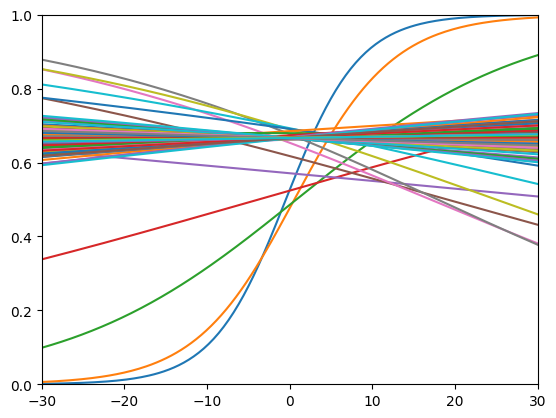

In [12]:
%matplotlib inline
xmin, xmax, ymin, ymax = -30, 30, 0, 1
for epoch in range(0,2000, 20):
    phi = dis_phi[epoch]
    x_ax = np.linspace(xmin, xmax, 200)
    plt.plot(x_ax, p(x_ax, phi[0], phi[1]))
    plt.axis([xmin, xmax, ymin, ymax])

This is a bit meaningless unless you looked at the graphs before it and notice that the training has sort of a yo-yo effect (for lack of a more descriptive term). The discriminator swings completely around and then wiggles around a somewhat flat curve. Below we will plot some epochs individually over time, choose them according to the approximate second derivative of the "Generator parameter over epochs" graph above to get nice looking curves.

In [13]:
def plot_probas(epoch):
    # Get parameters, plot p(beta_0 + beta_1*x).
    phi = dis_phi[epoch]
    x_ax = np.linspace(xmin, xmax, 200)
    plt.plot(x_ax, p(x_ax, phi[0], phi[1]))
    plt.axis([xmin, xmax, ymin, ymax])
    plt.title("Discriminator probabilities at epoch {}".format(epoch))

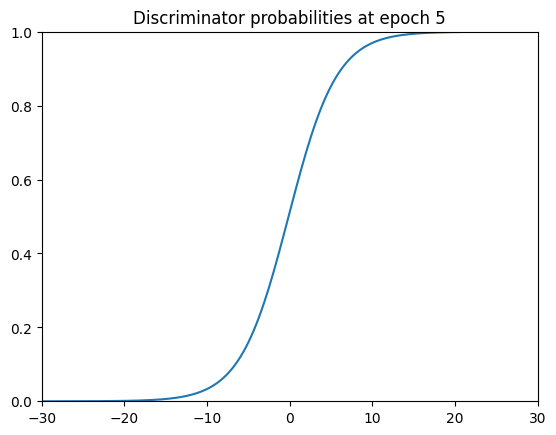

In [14]:
plot_probas(5)

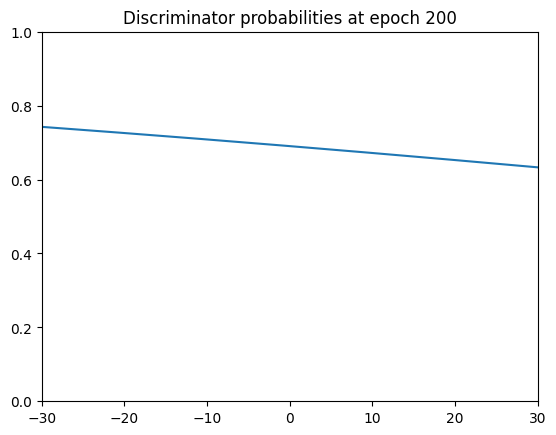

In [ ]:
plot_probas(200)

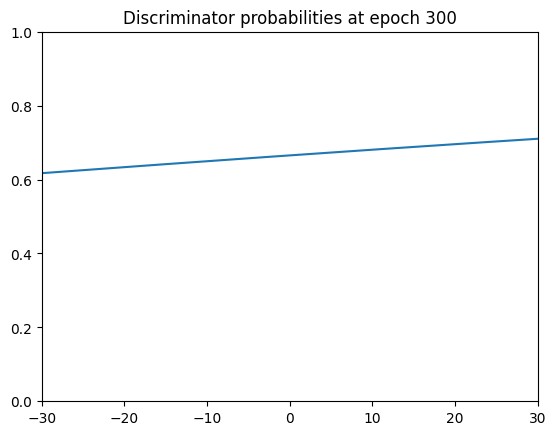

In [15]:
plot_probas(300)

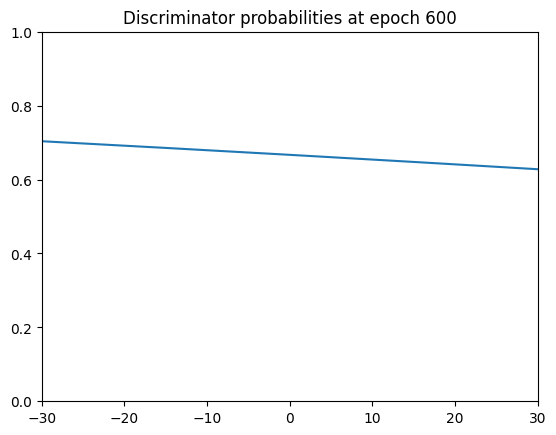

In [16]:
plot_probas(600)

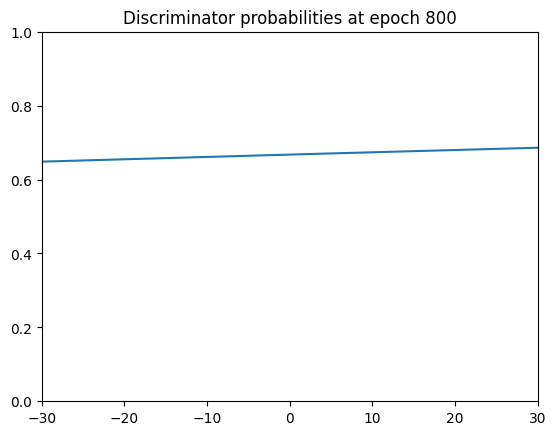

In [17]:
plot_probas(800)

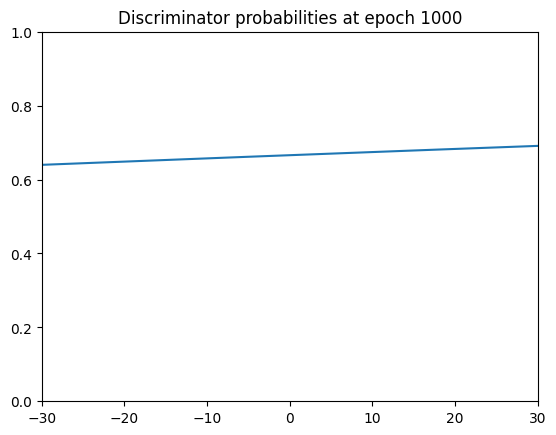

In [18]:
plot_probas(1000)

Things are pretty much flat after epoch 1000. This means that the discriminator is very confused. If your curves are not pretty much flat at this point, something went very wrong during your error propagation.

## Bonus

Modify the training loop for stochastic gradient descent (one example at a time). What can you say about the loss graphs of the generator/discriminator compared to the ones trained with gradient descent?

In [19]:
# Set the true mean
M = 6

# Set the amount of fake generated samples and true samples.
m, n = 30, 60

# Training epochs
epochs = 2000

In [20]:
def train_sto(gen_train_steps=1, dis_train_steps=2):
    for i in range(gen_train_steps):
        # Generate some fake data
        noise = np.random.normal(size=1)
        fake_data = generator.generate(noise)


        # What does the discriminator think?
        discriminator_out = discriminator.evaluate(fake_data)

        # Compute the loss of the generator.
        gen_labels = np.ones(shape=discriminator_out.shape[0])
        gen_loss = bce_loss(gen_labels, fake_data)

        # compute gradients dL/dtheta
        dL_dyhat = (-(gen_labels/discriminator_out)) + ((1-gen_labels)/(1-discriminator_out))
        dyhat_dx =  discriminator_out* (1-discriminator_out)*discriminator.phi[1]
        dx_dtheta = 1
        dL_dtheta = dL_dyhat * dyhat_dx * dx_dtheta

        # average the gradients
        dL_dtheta = 1/fake_data.shape[0] * np.sum(dL_dtheta)

        # optimize
        generator.optimize(dL_dtheta)

    for i in range(dis_train_steps):
        # Get some real data and mix it with fake data
        real_data = np.random.normal(loc=M, size=1)
        noise = np.random.normal(size=1)
        fake_data = generator.generate(noise)
        data = np.concatenate([fake_data, real_data])
        labels = np.concatenate([np.zeros(shape=fake_data.shape[0]), np.ones(shape=real_data.shape[0])])


        # Pass data through discriminator, compute loss
        discriminator_out = discriminator.evaluate(data)
        dis_loss = bce_loss(discriminator_out, labels)

        # compute gradients dL/dbeta0 and dL/dbeta1
        dL_dyhat = -(labels/discriminator_out)+ ((1-labels)/(1-discriminator_out))
        dyhat_dbeta0 = discriminator_out*(1-discriminator_out)
        dyhat_dbeta1 = discriminator_out*(1-discriminator_out) * data
        #
        dL_dbeta0 = dL_dyhat * dyhat_dbeta0
        dL_dbeta1 = dL_dyhat * dyhat_dbeta1

        # average the gradients
        dL_dbeta0 = 1/data.shape[0] * np.sum(dL_dbeta0)
        dL_dbeta1 = 1/data.shape[0] * np.sum(dL_dbeta1)

        # optimize
        discriminator.optimize(np.array([dL_dbeta0, dL_dbeta1]))

    return np.mean(gen_loss), np.mean(dis_loss)

def print_stats():
    print("Generator mean: {}".format(generator.theta))

In [21]:
# Instantiate our gen/dis objects
generator = Gen(theta=0.0, lr=0.1)
discriminator = Dis(lr=0.1)

# Saving some training data
gen_loss, dis_loss = [], []
gen_theta = []
dis_phi = []
for i in range(epochs):
    g, d = train_sto(gen_train_steps=10, dis_train_steps=1)

    # Save the losses of the generator and discriminator
    gen_loss.append(g)
    dis_loss.append(d)
    gen_theta.append(generator.theta)
    dis_phi.append(discriminator.phi)

gen_theta = np.array(gen_theta)
dis_phi = np.array(dis_phi)

Text(0.5, 1.0, 'Generator BCE Loss over epochs')

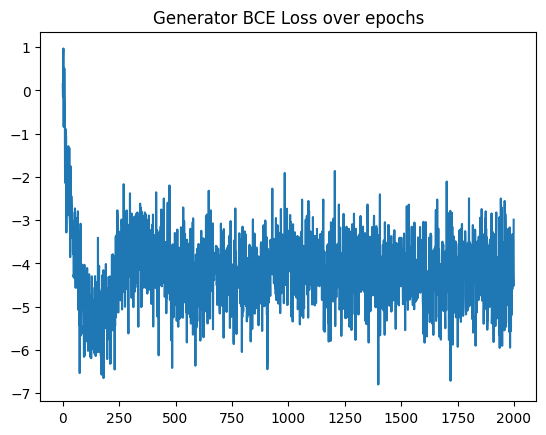

In [22]:
# Plot the generator loss
plt.plot(gen_loss)
plt.title("Generator BCE Loss over epochs")

Text(0.5, 1.0, 'Generator parameter over epochs')

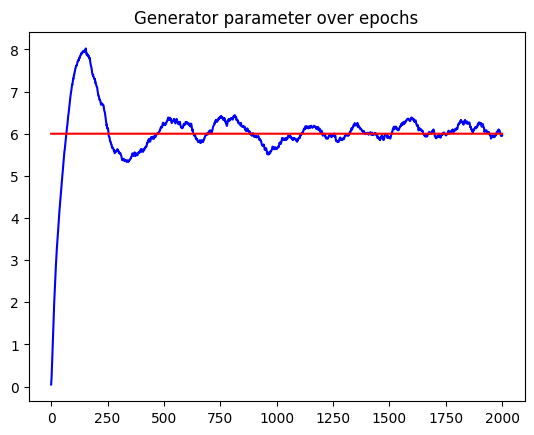

In [23]:
# Plot the generator's mean parameter over epochs. It should converge to the true mean.
plt.plot(np.arange(epochs), gen_theta, c='b')
plt.plot(np.arange(epochs), np.ones(shape=(epochs,))*M, c='r')
plt.title("Generator parameter over epochs")

from the figure above, the generator parameter over epoches converges faster than the batches, however, after the convergence, it oscilates much more arounf the mean than the former method.